Requested Citation Acknowledgment:
IEEE OTCBVS WS Series Bench; J. Davis and M. Keck, "A two-stage approach to person detection in thermal imagery," In Proc. Workshop on Applications of Computer Vision, January 2005

# Imports

In [51]:
### Object Detection with Faster R-CNN and RetinaNet in PyTorch - Template Code for Assignment 3 (2026 Spring) ###

### Might need to install the following packages if you haven't already: ###
### You can run these commands in your terminal or uncomment and run them in a notebook cell. ###
# !pip -q install torch torchvision torchmetrics matplotlib
# !pip install pandas
# !pip install pycocotools
# !pip install faster-coco-eval
#!pip install tqdm

import re, random, time
from pathlib import Path
from typing import List, Dict, Tuple
import os

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


import torch
from torch.utils.data import Dataset, DataLoader


import torchvision
from torchvision.transforms import functional as TF
from torchvision.models.detection import RetinaNet_ResNet50_FPN_V2_Weights, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection import retinanet_resnet50_fpn_v2
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchmetrics.detection.mean_ap import MeanAveragePrecision


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Data Preprocessing and creating data Loaders

In [52]:
### Helper function for loading and parsing the OSU Thermal Pedestrian Database (OTCBVS) ground-truth files. ###
### Needs to be adapted if you want to use a different dataset. ###


# OSU Thermal Pedestrian Database (OTCBVS) ground-truth parser
# File format:
#   NumberOfFrames
#   img_00001.bmp 4 (x1 y1 x2 y2) (x1 y1 x2 y2) ...
# Notes:
# - Coordinates are pixel indices in the original image (360x240).
# - We'll keep boxes in torchvision format: [x1, y1, x2, y2] (float32)

_BOX_RE = re.compile(r"\((\d+)\s+(\d+)\s+(\d+)\s+(\d+)\)")

def parse_groundtruth_txt(gt_path: str) -> Dict[str, torch.Tensor]:
    with open(gt_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [
            ln.strip() for ln in f.readlines()
            if ln.strip() and not ln.strip().startswith("%")
        ]

    n_frames = int(lines[0])
    records = lines[1:1 + n_frames]

    out: Dict[str, torch.Tensor] = {}
    for ln in records:
        parts = ln.split()
        fname = parts[0]

        boxes = []
        for m in _BOX_RE.finditer(ln):
            x1, y1, x2, y2 = map(float, m.groups())
            # Safety: ensure proper ordering
            x1, x2 = min(x1, x2), max(x1, x2)
            y1, y2 = min(y1, y2), max(y1, y2)
            boxes.append([x1, y1, x2, y2])

        if boxes:
            out[fname] = torch.tensor(boxes, dtype=torch.float32)
        else:
            out[fname] = torch.zeros((0, 4), dtype=torch.float32)

    return out

In [55]:
class ThermalDataset(Dataset):
    def __init__(self, base, video_folders, transforms=None):
        super().__init__()
        self.transforms = transforms
        self.base = base
        self.video_folders = video_folders
        self.all_frames = list()
        self.idxs = list()
        self.lengths = list()
        seqIdx = 0

        for seq in video_folders:
            self.idxs.append(int(seq)-1)
            seq_path = os.path.join(base,seq)
            gt_file = os.path.join(seq_path,"groundTruth.txt")
            annotations = parse_groundtruth_txt(gt_path=gt_file)
            self.lengths.append(0)
            for img_name, annotation in annotations.items():
                img_path = os.path.join(seq_path,img_name)
                self.all_frames.append((img_path, annotation))
                self.lengths[seqIdx] += 1

            seqIdx += 1

    def __len__(self):
        return len(self.all_frames)
    
    def get_idxs(self):
        return self.idxs
    
    def __getitem__(self, index):
        path, annotation = self.all_frames[index]
        img = Image.open(path).convert("RGB")

        temp = index
        for length in self.lengths:
            if temp > length:
                temp -= length
            else:
                break

        target = {
            "boxes": annotation,
            "labels": torch.ones(len(annotation), dtype=torch.int64),
            "image_id": torch.tensor(temp)
        }

        if self.transforms != None:
            img = self.transforms(img)

        return img, target

Total images found: 284
Sequence ids present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Train: 187  |   Test: 97


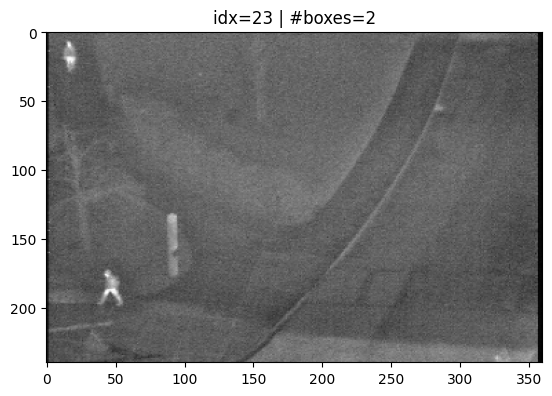

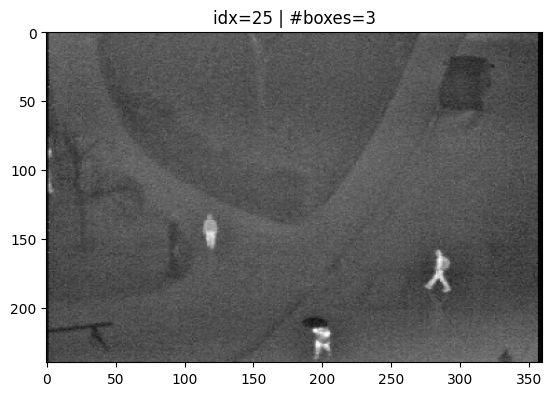

In [ ]:
def create_data_loaders(DATASET_PATH):    
    test_ratio = 0.2
    sorted_path = sorted(os.listdir(DATASET_PATH))
    train_paths = sorted_path[:-int(test_ratio*len(sorted_path))]
    test_paths = sorted_path[-int(test_ratio*len(sorted_path)):]

    train_dataset = ThermalDataset(base=DATASET_PATH,video_folders=train_paths)
    test_dataset = ThermalDataset(base=DATASET_PATH, video_folders=test_paths)
    total_size = train_dataset.__len__()+test_dataset.__len__()
    print(f"Total images found: {total_size}")
    print(f"Sequence ids present: {train_dataset.get_idxs()+test_dataset.get_idxs()}")
    print(f"Train: {train_dataset.__len__()}  |   Test: {test_dataset.__len__()}")

    def collate_fn(batch):
        images, targets = zip(*batch)
        return list(images), list(targets)

    train_loader = DataLoader(train_dataset,batch_size=4,shuffle=True,collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset,batch_size=4,shuffle=False,collate_fn=collate_fn)

    return train_loader, test_loader



DATASET_PATH = os.path.join(".", "OSU_Thermal_Detection")
train_loader,test_loader = create_data_loaders(DATASET_PATH)

dataiter = iter(train_loader)
images, labels = next(dataiter)

for i in range(2):
    plt.imshow(images[i])
    plt.title(f"idx={labels[i]['image_id']} | #boxes={len(labels[i]['boxes'])}") 
    plt.show()


# Visualize two samples of the Training Data

Total images found: 284
Sequence ids present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Train: 187  |  Test: 97


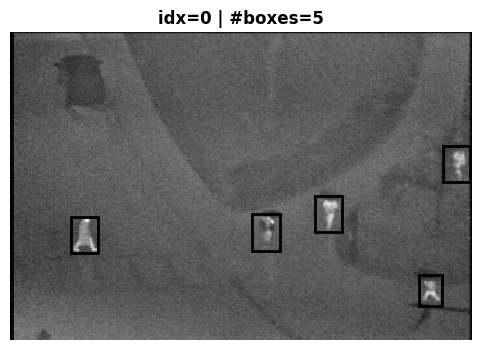

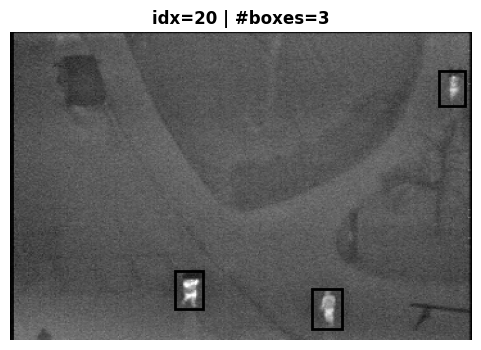

# Create the following methods for training and evaluation:
### 1.train_one_epoch
### 2.evaluate_map (mean Average Precision)
### 3.time_inference

In [ ]:
def train_one_epoch(model, loader, optimizer, device, epoch=None):
    ### You Code Here ###



@torch.no_grad()
def evaluate_map(model, loader, device):
    """mAP evaluation using torchmetrics.
    Returns a dict with keys like 'map', 'map_50', 'mar_100', ...
    """
    ### You Code Here ##
    
    return metric.compute()


@torch.no_grad()
def time_inference(model, dataset, device, n_images=100, warmup=10):
    """Average inference time per image (ms)."""
    ### You Code Here ###

    return float(np.mean(times)), float(np.std(times))


# Create Two-stage detector: Faster R-CNN (Region Proposal + classifier)

We'll fine-tune a Faster R-CNN model. To do this you will 
1- Load the fasterRCN.
2- Freeze the backbone.
3- create an optimizer for it. SGD with lr=0.005, momentum=0.9, weight_decay=0.0005

Note: In TorchVision detection models like Faster R-CNN, num_classes means: number of foreground categories + 1 background class

## Train for small number of epochs

Epoch 1:   0%|          | 0/47 [00:00<?, ?it/s]

[FasterRCNN] ep=1 | loss=0.3901 | time=58.2s | mAP=0.471 | mAP50=0.905


Epoch 2:   0%|          | 0/47 [00:00<?, ?it/s]

[FasterRCNN] ep=2 | loss=0.2427 | time=61.5s | mAP=0.565 | mAP50=0.949


Epoch 3:   0%|          | 0/47 [00:00<?, ?it/s]

[FasterRCNN] ep=3 | loss=0.2153 | time=57.9s | mAP=0.583 | mAP50=0.971


# Create One-stage detector: RetinaNet

We'll fine-tune RetinaNet. To do this you will:
1- Load the RetinaNet.
2- Freeze the backbone.
3- create an optimizer for it. SGD with lr=0.005, momentum=0.9, weight_decay=0.0005


Note: In TorchVision detection models, num_classes means: number of foreground categories + 1 background class


Epoch 1:   0%|          | 0/47 [00:00<?, ?it/s]

[RetinaNet ] ep=1 | loss=1.2612 | time=38.1s | mAP=0.000 | mAP50=0.000


Epoch 2:   0%|          | 0/47 [00:00<?, ?it/s]

[RetinaNet ] ep=2 | loss=0.7375 | time=37.7s | mAP=0.536 | mAP50=0.921


Epoch 3:   0%|          | 0/47 [00:00<?, ?it/s]

c:\Users\javshe\AppData\Local\anaconda3\envs\torch_cuda\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


[RetinaNet ] ep=3 | loss=0.5245 | time=37.4s | mAP=0.576 | mAP50=0.941


## Calculate val_mAP, val_mAP50, mean_infer_ms for both methods

Two-stage Faster R-CNN: 183.63 ± 5.68 ms/image
One-stage RetinaNet:   122.67 ± 1.65 ms/image


,model,final_test_mAP,final_test_mAP50,mean_infer_ms
0,Faster R-CNN (two-stage),0.583290,0.970599,183.633037
1,RetinaNet (one-stage),0.575879,0.940925,122.672494


## Visualize the results of two methods for couple of images from test set

Faster R-CNN predictions:


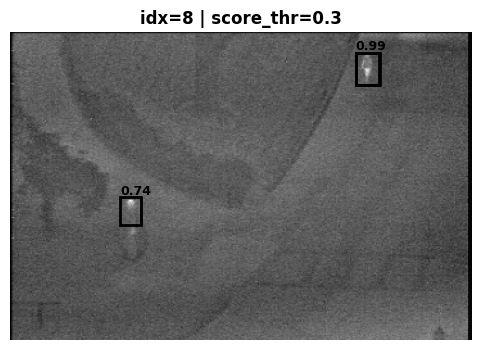

RetinaNet predictions:


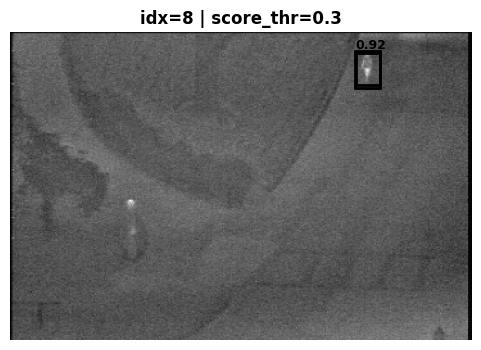

## write your conclusion  for the results you got